# Setup and Initialization
This file contains useful functions primarily from the `sympy` library so that calculations relating to the Laplace transform become much simpler. We also import `numpy` and `matplotlib` for numerical evaluation and plotting.

In [1]:
import sympy as sym
from sympy.abc import s, t, x, y, z
from sympy.integrals import laplace_transform, inverse_laplace_transform
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal

# Keep outputs pretty in Jupyter
sym.init_printing()

### 1. Core Laplace Toolbox
The `laplace_transform(function, time_var, s_var)` converts the time domain ($t$) to the complex frequency domain ($s$)

In [2]:
# Function in t-domain
F = 5 * t**2

# Laplace transform (t -> s)
# The function returns a tuple: (result, convergence_conditions, evaluation_conditions)
# We usually only need the first element [0]
U = laplace_transform(F, t, s)
print("Laplace Transform of 5t^2:")
display(U[0])

# Inverse Laplace transform (s -> t)
# Converts s-domain back to time
f_inv = inverse_laplace_transform(U[0], s, t)
print("Inverse Transform:")
display(f_inv)

Laplace Transform of 5t^2:


Inverse Transform:


### 2. Transfer Functions: Partial Fractions & Roots
For advanced inverse Laplace calculations and discovering zeros and poles, we can utilize `sym.apart()` to split a fraction, `sym.expand()` to multiply polynomials, and `sym.roots()` to find poles.

Partial Fractions:


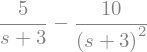

Expanded Denominator:


System Poles (Roots of Denominator):


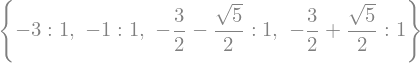

In [3]:
# Fractional form of a function in s-domain
G = 5 * (s + 1) / (s + 3)**2

# Partial fraction decomposition
print("Partial Fractions:")
display(sym.apart(G))

# Analyzing the denominator of a transfer function
d1 = (s + 1) * (s + 3) * (s**2 + 3*s + 1)

# Expand polynomial
d2 = sym.expand(d1)
print("Expanded Denominator:")
display(d2)

# Find roots (poles of the system)
print("System Poles (Roots of Denominator):")
display(sym.roots(d2))

### 3. Advanced Laplace Math
When working with controls or circuits, you frequently need step functions, impulses, and the Initial/Final Value theorems to predict system behavior without fully inversing the equation.

In [4]:
# 1. Special Functions: Heaviside (Step) and Dirac Delta (Impulse)
step_func = sym.Heaviside(t)
impulse_func = sym.DiracDelta(t)

print("Laplace of Unit Step:")
display(laplace_transform(step_func, t, s)[0])

# 2. Initial and Final Value Theorems
# FVT: limit as s -> 0 of s*F(s) gives the steady-state time value
# IVT: limit as s -> infinity of s*F(s) gives the initial time value
F_s = 5 / (s * (s + 2)) # Represents a step response of a first-order system

steady_state_value = sym.limit(s * F_s, s, 0)
initial_value = sym.limit(s * F_s, s, sym.oo)

print(f"Initial Value (t=0): {initial_value}")
print(f"Steady State Value (t=inf): {steady_state_value}")

Laplace of Unit Step:


Initial Value (t=0): 0
Steady State Value (t=inf): 5/2


### 4. Complex Signal Example
Analyzing a piecewise function combining delayed steps and ramps. (Note: Using `sym.lambdify` converts symbolic equations into fast NumPy functions, avoiding the extremely slow nested `subs` loop from the original script).

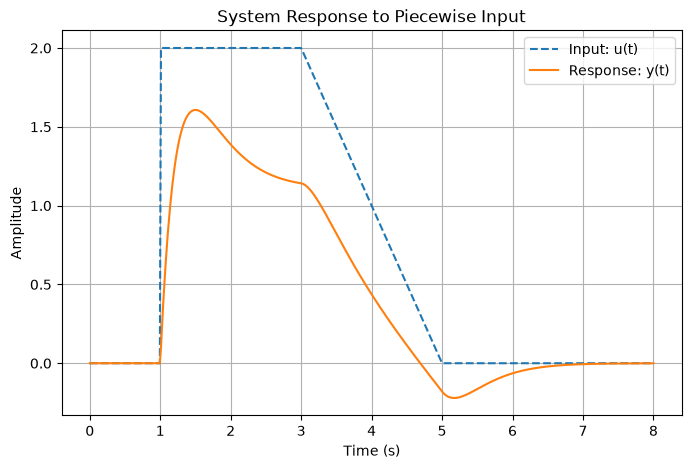

In [5]:
# Define inputs in s-domain using exponential delays
U1 = (2/s) * sym.exp(-s)          # Step up at 1 sec
U2 = (-1/s**2) * sym.exp(-3*s)    # Ramp down starts at 3 sec
U3 = (1/s**2) * sym.exp(-5*s)     # Ramp neutralizes at 5 sec

U_total = U1 + U2 + U3

# Transfer function
G = 5 * (s + 1) / (s + 3)**2

# Calculate system response in s-domain
Y_total = G * U_total

# Inverse Laplace Transform to time domain
u_t = inverse_laplace_transform(U_total, s, t)
y_t = inverse_laplace_transform(Y_total, s, t)

# Generate data for plot
tm = np.linspace(0, 8, 500)

# Use lambdify to evaluate the sympy expression across the numpy array instantly
u_func = sym.lambdify(t, u_t, modules=['numpy', 'sympy'])
y_func = sym.lambdify(t, y_t, modules=['numpy', 'sympy'])

us = np.real(u_func(tm)) # Real forces evaluation of complex artifacts
ys = np.real(y_func(tm))

# Plot results
plt.figure(figsize=(8,5))
plt.plot(tm, us, label='Input: u(t)', linestyle='--')
plt.plot(tm, ys, label='Response: y(t)')
plt.title("System Response to Piecewise Input")
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()

### 5. Practical Circuit Analysis: RLC Low-Pass Filter
For real circuit analysis, `sympy` is used to derive the transfer function $H(s)$, and `scipy.signal` is used to simulate the Bode plots and step responses standard in engineering.Circuit: Series RLC circuit taking voltage across the capacitor.
- $Z_R = R$
- $Z_L = sL$
- $Z_C = \frac{1}{sC}$
- $H(s) = \frac{Z_C}{Z_R + Z_L + Z_C} = \frac{1}{LCs^2 + RCs + 1}$

Symbolic Transfer Function H(s):


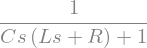


Numerical Transfer Function:


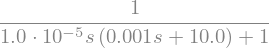

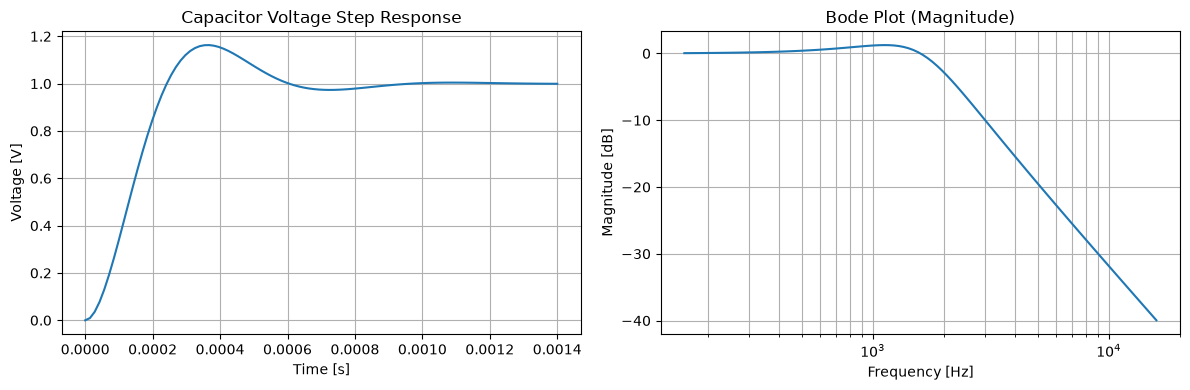

In [6]:
# 1. Define Circuit Parameters
R_val = 10.0      # Ohms
L_val = 1e-3      # 1 mH
C_val = 10e-6     # 10 uF

# 2. Derive Symbolic Transfer Function
R, L, C = sym.symbols('R L C', positive=True)
Z_R = R
Z_L = s * L
Z_C = 1 / (s * C)

H_sym = Z_C / (Z_R + Z_L + Z_C)
H_sym = sym.simplify(H_sym)
print("Symbolic Transfer Function H(s):")
display(H_sym)

# 3. Substitute component values
H_subbed = H_sym.subs({R: R_val, L: L_val, C: C_val})
print("\nNumerical Transfer Function:")
display(H_subbed)

# Extract numerator and denominator coefficients for SciPy
# H(s) = 1 / (1e-08*s^2 + 0.0001*s + 1)
num = [1]
den = [L_val * C_val, R_val * C_val, 1]

# Create LTI (Linear Time-Invariant) System
sys = signal.TransferFunction(num, den)

# 4. Analyze Circuit Behavior (Step Response & Bode Plot)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Step Response (Time Domain)
t_step, y_step = signal.step(sys)
ax1.plot(t_step, y_step)
ax1.set_title('Capacitor Voltage Step Response')
ax1.set_xlabel('Time [s]')
ax1.set_ylabel('Voltage [V]')
ax1.grid()

# Bode Plot (Frequency Domain)
w, mag, phase = signal.bode(sys)
ax2.semilogx(w / (2 * np.pi), mag) # Convert rad/s to Hz
ax2.set_title('Bode Plot (Magnitude)')
ax2.set_xlabel('Frequency [Hz]')
ax2.set_ylabel('Magnitude [dB]')
ax2.grid(which='both', axis='both')

plt.tight_layout()
plt.show()